## Install Kaggle API

In [2]:
%pip install kagglehub


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Download Kaggle dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

/Users/priscillaashleywijaya/Desktop/General/NUS_Fintech_Society/capstone/src/CreditShield/capstone/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/priscillaashleywijaya/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## Requirements

In [4]:
import re
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# "magic" command to make plots show up in the notebook
%matplotlib inline 

# Data analysis

In [5]:
folders = os.listdir(path)
# Skip .xslx file, if we are ever able to upload it...
# Currently can't upload due to conflicts with other versions of the dataset on Kaggle.
folders = [f for f in folders if 'xlsx' not in f]
folders

['rejected_2007_to_2018q4.csv',
 'accepted_2007_to_2018q4.csv',
 'rejected_2007_to_2018Q4.csv.gz',
 'accepted_2007_to_2018Q4.csv.gz']

In [6]:
os.listdir(path + "/" + folders[1])

['accepted_2007_to_2018Q4.csv']

In [7]:
acc_folder = path + "/" + [f for f in folders if 'accepted' in f][0]
accepted_fn = acc_folder + '/' + os.listdir(acc_folder)[0]

rej_folder = path + "/" + [f for f in folders if 'rejected' in f][0]
rejected_fn = rej_folder + '/' + os.listdir(rej_folder)[0]

accepted_fn

'/Users/priscillaashleywijaya/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv'

In [8]:
# check if the actual file is still there
if os.path.isfile(accepted_fn) and os.path.isfile(rejected_fn):
    print('both paths point to the actual file')
else:
    print('locate files manually')

both paths point to the actual file


In [9]:
# reading the csv
acc_df = pd.read_csv(accepted_fn)
rej_df = pd.read_csv(rejected_fn)

/var/folders/tg/g161x0m50lxgx68hfwk_3qk80000gn/T/ipykernel_4643/578552646.py:2: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  acc_df = pd.read_csv(accepted_fn)


In [10]:
acc_df.shape 

(2260701, 151)

2260701 rows, 151 columns in accepted file

In [11]:
rej_df.shape

(27648741, 9)

27648741 rows, 9 columns in accepted file

### FICO Score
- FICO stands for Fair Isaac Corporation, the company that created one of the most widely used credit scoring systems in the United States.

- A FICO score is a numerical measure of a person's creditworthiness — basically, how likely they are to repay a loan.

In [12]:
# fico score in accepted loans
[col for col in acc_df.columns if 'fico' in col.lower()]

['fico_range_low',
 'fico_range_high',
 'last_fico_range_high',
 'last_fico_range_low',
 'sec_app_fico_range_low',
 'sec_app_fico_range_high']

In [13]:
# fico score in rejected loans
[col for col in rej_df.columns if 'fico' in col.lower()]

[]

### Rejected information

In [14]:
rej_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27648741 entries, 0 to 27648740
Data columns (total 9 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Amount Requested      float64
 1   Application Date      object 
 2   Loan Title            object 
 3   Risk_Score            float64
 4   Debt-To-Income Ratio  object 
 5   Zip Code              object 
 6   State                 object 
 7   Employment Length     object 
 8   Policy Code           float64
dtypes: float64(3), object(6)
memory usage: 1.9+ GB


## Accepted information

In [ ]:
acc_df['emp_title'].unique()

array(['leadman', 'Engineer', 'truck driver', ..., 'Sr. Photo Producer',
       'Exec Dir Internal Audit', 'Current Operations Officer'],
      shape=(512695,), dtype=object)

: 

In [15]:
acc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [16]:
pd.options.display.max_rows

In [17]:
acc_df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [18]:
acc_df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.00,Aug-2003,675.00,679.00,1.00,30.00,NaN,7.00,0.00,2765.00,29.70,13.00,w,0.00,0.00,4421.72,4421.72,3600.00,821.72,0.00,0.00,0.00,Jan-2019,122.67,NaN,Mar-2019,564.00,560.00,0.00,30.00,1.00,Individual,NaN,NaN,NaN,0.00,722.00,144904.00,2.00,2.00,0.00,1.00,21.00,4981.00,36.00,3.00,3.00,722.00,34.00,9300.00,3.00,1.00,4.00,4.00,20701.00,1506.00,37.20,0.00,0.00,148.00,128.00,3.00,3.00,1.00,4.00,69.00,4.00,69.00,2.00,2.00,4.00,2.00,5.00,3.00,4.00,9.00,4.00,7.00,0.00,0.00,0.00,3.00,76.90,0.00,0.00,0.00,178050.00,7746.00,2400.00,13734.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.00,Dec-1999,715.00,719.00,4.00,6.00,NaN,22.00,0.00,21470.00,19.20,38.00,w,0.00,0.00,25679.66,25679.66,24700.00,979.66,0.00,0.00,0.00,Jun-2016,926.35,NaN,Mar-2019,699.00,695.00,0.00,NaN,1.00,Individual,NaN,NaN,NaN,0.00,0.00,204396.00,1.00,1.00,0.00,1.00,19.00,18005.00,73.00,2.00,3.00,6472.00,29.00,111800.00,0.00,0.00,6.00,4.00,9733.00,57830.00,27.10,0.00,0.00,113.00,192.00,2.00,2.00,4.00,2.00,NaN,0.00,6.00,0.00,5.00,

In [19]:
acc_df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.00,40000.00,40000.00,60 months,10.49,859.56,B,B3,Vice President,9 years,MORTGAGE,227000.00,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,907xx,CA,12.75,7.00,Feb-1995,705.00,709.00,1.00,9.00,NaN,5.00,0.00,8633.00,64.90,37.00,f,23252.59,23252.59,24903.93,24903.93,16747.41,8156.52,0.00,0.00,0.00,Mar-2019,859.56,Apr-2019,Mar-2019,724.00,720.00,0.00,10.00,1.00,Individual,NaN,NaN,NaN,0.00,0.00,28398.00,0.00,2.00,0.00,1.00,15.00,19765.00,46.00,0.00,0.00,5141.00,51.00,13300.00,3.00,0.00,2.00,2.00,5680.00,4070.00,66.90,0.00,0.00,154.00,258.00,33.00,15.00,3.00,41.00,9.00,1.00,9.00,6.00,2.00,3.00,2.00,15.00,9.00,3.00,23.00,3.00,5.00,0.00,0.00,7.00,0.00,75.70,50.00,0.00,0.00,55970.00,28398.00,12300.00,42670.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.00,24000.00,24000.00,60 months,14.49,564.56,C,C4,Program Manager,6 years,RENT,110000.00,Not Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,334xx,FL,18.30,0.00,Jul-1999,660.00,664.00,0.00,67.00,72.00,10.00,1.00,17641.00,68.10,31.00,f,0.00,0.00,6755.40,6755.40,3521.91,3233.49,0.00,0.00,0.00,Oct-2017,564.56,NaN,Mar-2019,594.00,590.00,0.00,67.00,1.00,Individual,NaN,NaN,NaN,0.00,0.00,62426.00,0.00,2.00,0.00,2.00,20.00,44785.00,78.00,1.00,5.00,6172.00,73.00,25900.00,0.00,0.00,1.00,7.00,6243.00,4660.00,77.50,0.00,0.00,132.00,206.00,9.00,9.

In [20]:
acc_df.info(verbose = True, max_cols=None)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    id                                          object 
 1    member_id                                   float64
 2    loan_amnt                                   float64
 3    funded_amnt                                 float64
 4    funded_amnt_inv                             float64
 5    term                                        object 
 6    int_rate                                    float64
 7    installment                                 float64
 8    grade                                       object 
 9    sub_grade                                   object 
 10   emp_title                                   object 
 11   emp_length                                  object 
 12   home_ownership                              object 
 13   annual_inc

In [21]:
acc_df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260664.00,2258957.00,2260639.00,2260668.00,2260668.00,2260638.00,1102166.00,359156.00,2260639.00,2260639.00,2260668.00,2258866.00,2260639.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260523.00,580775.00,2260668.00,120710.00,120706.00,2260639.00,2190392.00,2190392.00,1394538.00,1394539.00,1394539.00,1394539.00,1350744.00,1394539.00,1191818.00,1394539.00,1394539.00,1394539.00,1394320.00,2190392.00,1394539.00,1394538.00,1394538.00,2210638.00,2190322.00,2185733.00,2184597.00,2260523.00,2260639.00,2121597.00,2190391.00,2190391.00,2190392.00,2210638.00,2187256.00,519701.00,1965233.00,740359.00,2190392.00,2190392.00,2190392.00,2202078.00,2190392.00,2190392.00,2190392.00,2190391.00,2190392.00,2202078.00,2107011.00,2190392.00,2190392.00,2190392.00,2190237.00,2185289.00,2259303.00,2260563.00,2190392.00,2210638.00,2210638.00,2190392.00,108020.00,108021.00,108021.00,108021.00,108021.00,108021.00,106184.00,108021.00,108021.00,108021.00,108021.00,35942.00,10917.00,10917.00,10917.00,10917.00,8651.00,10917.00,10917.00,34246.00,34246.00,34246.00
mean,NaN,15046.93,15041.66,15023.44,13.09,445.81,77992.43,18.82,0.31,698.59,702.59,0.58,34.54,72.31,11.61,0.20,16658.46,50.34,24.16,4206.89,4205.97,12082.56,12064.39,9505.77,2431.39,1.52,143.88,23.98,3429.35,687.66,675.54,0.02,44.16,1.00,123624.64,19.25,0.00,232.73,142492.20,0.93,2.78,0.68,1.56,21.22,35506.65,69.14,1.29,2.75,5806.39,57.03,34573.94,1.01,1.48,2.04,4.52,13547.80,11394.26,57.90,0.01,12.37,125.74,181.49,14.02,8.30,1.56,24.84,39.30,7.02,35.78,0.50,3.68,5.63,4.77,7.73,8.41,8.25,14.00,5.58,11.63,0.00,0.00,0.08,2.08,94.11,42.44,0.13,0.05,178242.75,51022.94,23193.77,43732.01,33617.28,669.76,673.76,0.63,1.54,11.47,58.17,3.01,12.53,0.05,0.08,36.94,3.00,155.05,3.00,13.74,454.80,11636.88,193.99,5010.66,47.78,13.19
std,NaN,9190.25,9188.41,9192.33,4.83,267.17,112696.20,14.18,0.87,33.01,33.01,0.89,21.90,26.46,5.64,0.57,22948.31,24.71,11.99,7343.24,7342.33,9901.38,9896.99,8321.85,2679.74,11.84,748.16,131.23,60

## Data Cleaning

In [22]:
# 1. Get the list of column names
column_list = acc_df.columns.tolist()

# 2. Iterate and print each column name on a new line
for col in column_list:
    print(col)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

In [23]:
data = acc_df.sample(100_000, random_state=42)

In [24]:
data["loan_status"].value_counts(dropna = False)

loan_status
Fully Paid                                             47460
Current                                                38887
Charged Off                                            12034
Late (31-120 days)                                       969
In Grace Period                                          368
Late (16-30 days)                                        187
Does not meet the credit policy. Status:Fully Paid        60
Does not meet the credit policy. Status:Charged Off       31
NaN                                                        4
Name: count, dtype: int64

In [25]:
def map_status(s):
    if s in ["Fully Paid", "Current", "In Grace Period"]:
        return 1
    if s in ["Charged Off", "Late (31-120 days)", "Late (16-30 days)"]:
        return 0
    return np.nan

data["loan_status_binary"] = data["loan_status"].apply(map_status)
data = data.dropna(subset=["loan_status_binary"])
data["loan_status_binary"] = data["loan_status_binary"].astype(int)

In [26]:
data.shape

(99905, 152)

In [27]:
data = data.loc[data['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data["loan_status"].value_counts(dropna = False)

loan_status
Fully Paid     47460
Charged Off    12034
Name: count, dtype: int64

### Retain only columns that do not leak & are known at point of application

In [28]:
print(sorted(data.columns))

['acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'all_util', 'annual_inc', 'annual_inc_joint', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'debt_settlement_flag_date', 'deferral_term', 'delinq_2yrs', 'delinq_amnt', 'desc', 'disbursement_method', 'dti', 'dti_joint', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'grade', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_flag', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'home_ownership', 'id', 'il_util', 'initial_list_status', 'inq_fi', 'inq_last_12m', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', '

Using information online and the best knowledge we have to retain columns that do not leak information into the future & are not irrelevant
- Things Lending Club knows at application / approval:
    - borrower info: income, employment, purpose, state
    - credit bureau info: FICO, delinquencies, utilisation, counts
    - loan terms: amount, term, interest rate, grade
    - origination date: issue_d

In [29]:
cols_to_keep = [
    # Response variable (loan status)
    "loan_status",
    
    # Loan terms (known before issuing the loan)
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "funded_amnt",
    "funded_amnt_inv",
    "grade",
    "sub_grade",
    "initial_list_status",
    "disbursement_method",
    
    # Borrower attributes (application)
    "emp_title",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "application_type",    
    "issue_d",
    
    # Credit bureau attributes at time of application
    "dti",
    "delinq_2yrs",
    "earliest_cr_line",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "fico_range_low",
    "fico_range_high",
    'pymnt_plan',
    
    # Richer bureau attributes (still at application)
    "acc_open_past_24mths",
    "bc_open_to_buy",
    "bc_util",
    "chargeoff_within_12_mths",   # applicant’s past credit behaviour
    "collections_12_mths_ex_med",
    "delinq_amnt",
    "inq_fi",
    "inq_last_12m",
    "max_bal_bc",
    "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op",
    "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl",
    "mort_acc",
    "mths_since_last_delinq",
    "mths_since_last_major_derog",
    "mths_since_last_record",
    "mths_since_rcnt_il",
    "num_accts_ever_120_pd",
    "num_actv_bc_tl",
    "num_actv_rev_tl",
    "num_bc_sats",
    "num_bc_tl",
    "num_il_tl",
    "num_op_rev_tl",
    "num_rev_accts",
    "num_rev_tl_bal_gt_0",
    "num_sats",
    "num_tl_120dpd_2m",
    "num_tl_30dpd",
    "num_tl_90g_dpd_24m",
    "num_tl_op_past_12m",
    "open_acc_6m",
    "open_act_il",
    "open_il_12m",
    "open_il_24m",
    "open_rv_12m",
    "open_rv_24m",
    "pct_tl_nvr_dlq",
    "percent_bc_gt_75",
    "pub_rec_bankruptcies",
    "tax_liens",
    "tot_hi_cred_lim",
    "total_bal_ex_mort",
    "total_bal_il",
    "total_bc_limit",
    "total_cu_tl",
    "total_il_high_credit_limit",
]

In [30]:
cols_to_drop = [col for col in data.columns if col not in cols_to_keep]
print(cols_to_drop)
print(len(cols_to_drop))

['id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'addr_state', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'policy_code', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'il_util', 'all_util', 'total_rev_hi_lim', 'avg_cur_bal', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'ha

In [31]:
data.drop(labels = cols_to_drop, inplace = True, axis = 1)

In [32]:
data.shape

(59494, 79)

In [33]:
data.sample(10)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,open_rv_12m,open_rv_24m,max_bal_bc,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method
1796767,28000.00,28000.00,28000.00,60 months,17.10,697.38,C,C5,Fairway Independent Mortgage Co,2 years,MORTGAGE,120000.00,Verified,Sep-2013,Charged Off,n,debt_consolidation,13.00,0.00,May-2000,710.00,714.00,0.00,64.00,NaN,15.00,0.00,35574.00,67.90,49.00,f,0.00,64.00,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.00,12188.00,72.50,0.00,0.00,136.00,162.00,2.00,2.00,2.00,1.00,2.00,4.00,5.00,13.00,22.00,12.00,25.00,4.00,15.00,0.00,0.00,0.00,4.00,98.00,50.00,0.00,0.00,396391.00,98607.00,44400.00,73729.00,Cash
328683,8050.00,8050.00,8050.00,36 months,13.33,272.52,C,C3,PROGRAM REPRESENTATIVE 1,3 years,MORTGAGE,44500.00,Source Verified,Apr-2015,Charged Off,n,debt_consolidation,3.16,1.00,Apr-2004,665.00,669.00,0.00,21.00,NaN,6.00,0.00,3153.00,30.00,16.00,w,0.00,NaN,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00,1100.00,0.00,0.00,0.00,131.00,101.00,10.00,4.00,3.00,0.00,0.00,3.00,1.00,3.00,5.00,5.00,8.00,3.00,6.00,0.00,0.00,0.00,2.00,93.70,0.00,0.00,0.00,222000.00,3153.00,1100.00,0.00,Cash
1107042,15000.00,15000.00,15000.00,36 months,9.17,478.19,B,B2,sales,5 years,OWN,170000.00,Not Verified,Jan-2016,Fully Paid,n,credit_card,8.70,0.00,Oct-1993,700.00,704.00,2.00,45.00,NaN,21.00,0.00,11342.00,33.60,26.00,w,0.00,64.00,Individual,3.00,3.00,1.00,2.00,11.00,34726.00,5.00,14.00,2113.00,0.00,1.00,4.00,16.00,12073.00,42.00,0.00,0.00,267.00,39.00,2.00,2.00,1.00,2.00,8.00,13.00,8.00,8.00,8.00,16.00,17.00,13.00,21.00,0.00,0.00,0.00,6.00,88.00,0.00,0.00,0.00,251493.00,46068.00,20800.00,45863.00,Cash
182759,14300.00,14300.00,14300.00,36 months,8.18,449.30,B,B1,Marketing/Sales,< 1 year,OWN,75000.00,Source Verified,Aug-2015,Fully Paid,n,debt_consolidation,20.18,0.00,Aug-2002,685.00,689.00,0.00,NaN,NaN,9.00,0.00,13841.00,71.00,14.00,w,0.00,NaN,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,1159.00,92.30,0.00,0.00,156.00,63.00,11.00,11.00,0.00,0.00,3.00,3.00,3.00,3.00,10.00,4.00,4.00,3.00,9.00,0.00,0.00,0.00,1.00,100.00,100.00,0.00,0.00,85783.00,62755.00,15000.00,66283.00,Cash
578068,5275.00,5275.00,5275.00,36 months,16.02,185.51,C,C5,Procurement Specialist,10+ years,RENT,60000.00,Not Verified,Aug-2017,Fully Paid,n,debt_consolidation,17.92,0.00,Nov-2005,660.00,664.00,0.00,35.00,91.00,5.00,1.00,2047.00,89.00,15.00,f,0.00,35.00,Joint App,0.00,3.00,0.00,1.00,20.00,82832.00,0.00,0.00,730.00,1.00,0.00,0.00,1.00,70.00,91.30,0.00,0.00,141.00,68.00,39.00,20.00,0.00,4.00,1.00,2.00,1.00,1.00,13.00,2.00,2.00,2.00,5.00,0.00,0.00,0.00,0.00,66.70,100.00,1.00,0.00,78199.00,84879.00,800.00,75899.00,Cash
1126962,12000.00,12000.00,11900.00,36 months,6.03,365.23,A,A1,Teacher,10+ years,MORTGAGE,68000.00,Not Verified,Dec-2014,Fully Paid,n,debt_consolidation,7.47,0.00,Aug-1988,765.00,769.00,2.00,81.00,NaN,15.00,0.00,10969.00,16.30,28.00,f,0.00,NaN,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,48007.

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59494 entries, 1273506 to 347653
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loan_amnt                    59494 non-null  float64
 1   funded_amnt                  59494 non-null  float64
 2   funded_amnt_inv              59494 non-null  float64
 3   term                         59494 non-null  object 
 4   int_rate                     59494 non-null  float64
 5   installment                  59494 non-null  float64
 6   grade                        59494 non-null  object 
 7   sub_grade                    59494 non-null  object 
 8   emp_title                    55660 non-null  object 
 9   emp_length                   56024 non-null  object 
 10  home_ownership               59494 non-null  object 
 11  annual_inc                   59494 non-null  float64
 12  verification_status          59494 non-null  object 
 13  issue_d       

In [35]:
data['term'] = np.where(data['term']==' 36 months', 36, 60)
data['issue_d'] = pd.to_datetime(data['issue_d'])
data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'])

/var/folders/tg/g161x0m50lxgx68hfwk_3qk80000gn/T/ipykernel_4643/3756829943.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['issue_d'] = pd.to_datetime(data['issue_d'])
/var/folders/tg/g161x0m50lxgx68hfwk_3qk80000gn/T/ipykernel_4643/3756829943.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'])


In [36]:
data['emp_length'].unique()

array([nan, '4 years', '10+ years', '5 years', '8 years', '7 years',
       '2 years', '6 years', '1 year', '3 years', '9 years', '< 1 year'],
      dtype=object)

## Pre-processing

In [37]:
# Want to determine if columns are categorical 
def analyze_categorical_features(df, unique_value_threshold=50):
    """
    Identifies and counts categories for columns that are either
    of 'object' type or have fewer unique values than the specified threshold.

    Args:
        df (pd.DataFrame): The DataFrame to analyze.
        unique_value_threshold (int): Max number of unique values a column
                                      can have to be considered categorical.

    Returns:
        dict: A dictionary where keys are column names and values are 
              their unique category counts.
    """
    categorical_counts = {}
    
    # 1. Identify candidate columns
    for col in df.columns:
        # Check if column is object type (string)
        if df[col].dtype == 'object':
            # Strings are always treated as categorical candidates
            is_categorical = True
        
        # Check if column is numeric but has a small number of unique values
        elif df[col].nunique() < unique_value_threshold:
            is_categorical = True
            
        else:
            is_categorical = False
            
        # 2. Store the count if it's a categorical candidate
        if is_categorical:
            # Drop NA values before counting unique categories
            count = df[col].nunique(dropna=True)
            categorical_counts[col] = count
            
    # Optional: Print results for easy viewing
    print(f"Found {len(categorical_counts)} categorical columns/candidates (Threshold: < {unique_value_threshold} unique values).")
    print("-" * 50)
    for col, count in sorted(categorical_counts.items(), key=lambda item: item[1], reverse=True):
        print(f"{col:<30} | Categories: {count}")
            
    return categorical_counts

# Example Usage (assuming your DataFrame is named 'data'):
# cat_summary = analyze_categorical_features(data)

In [38]:
missing_pct = data.isnull().sum() / len(data) * 100
high_missing_cols = missing_pct[missing_pct > 50].sort_values(ascending=False)
print(high_missing_cols)
print(f"\nTotal number of high-missing columns: {len(high_missing_cols)}")

mths_since_last_record        82.82
mths_since_last_major_derog   73.41
mths_since_rcnt_il            61.00
open_acc_6m                   59.97
open_act_il                   59.97
open_il_12m                   59.97
open_il_24m                   59.97
total_bal_il                  59.97
open_rv_12m                   59.97
open_rv_24m                   59.97
max_bal_bc                    59.97
inq_fi                        59.97
total_cu_tl                   59.97
inq_last_12m                  59.97
mths_since_last_delinq        50.22
dtype: float64

Total number of high-missing columns: 15


In [39]:
for col in data.columns:
    if data[col].dtype==object:
        print(data[col].value_counts())

grade
B    17236
C    16940
A    10197
D     9015
E     4239
F     1440
G      427
Name: count, dtype: int64
sub_grade
C1    3817
B5    3709
B4    3623
B3    3550
C2    3503
C3    3350
C4    3338
B2    3326
B1    3028
C5    2932
A5    2774
D1    2286
A4    2202
D2    2067
A1    1884
D3    1842
A2    1708
A3    1629
D4    1571
D5    1249
E1    1079
E2     997
E3     803
E4     706
E5     654
F1     462
F2     321
F3     255
F4     221
F5     181
G1     124
G2      90
G3      82
G4      74
G5      57
Name: count, dtype: int64
emp_title
Teacher                                        973
Manager                                        849
Owner                                          414
Registered Nurse                               394
RN                                             374
Supervisor                                     369
Sales                                          359
Driver                                         328
Project Manager                                264
O

In [40]:
# removing columns with low information (almost to fully constant values)
data = data.drop(columns=['pymnt_plan', 'application_type', 'disbursement_method'])
data.shape

(59494, 76)

## Visualisations

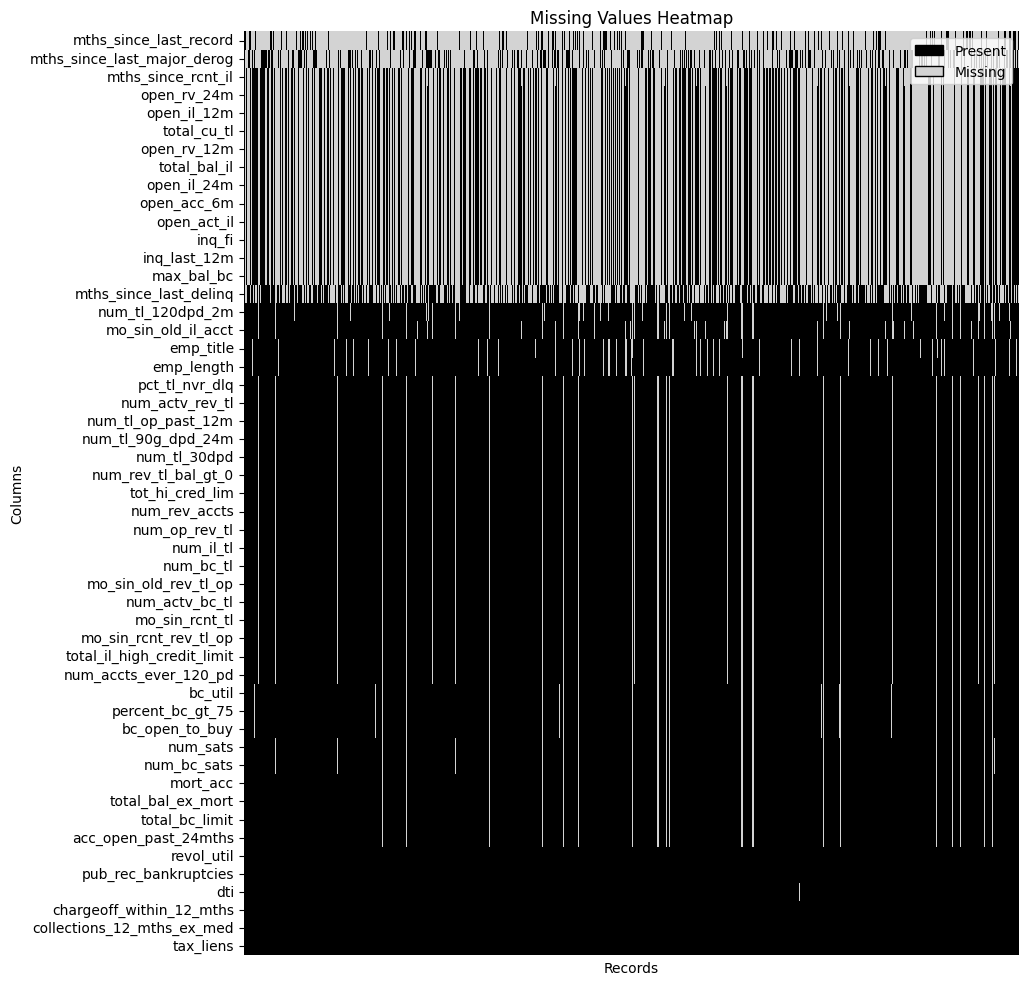

In [41]:
# missing values heatmap
na_ratio = data.isna().mean()
cols_with_na = na_ratio[na_ratio > 0].sort_values(ascending=False).index

# rotate heatmap so columns are on the y-axis for readability
plt.figure(figsize=(10, 12))
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["black", "lightgray"])
heatmap = sns.heatmap(
    data[cols_with_na].isna().T, cbar=False, xticklabels=False, yticklabels=cols_with_na, cmap=cmap
)
plt.title("Missing Values Heatmap")
plt.ylabel("Columns")
plt.xlabel("Records")

# add legend to indicate missing vs present
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor='black', edgecolor='black', label='Present'),
    Patch(facecolor='lightgray', edgecolor='black', label='Missing'),
]
plt.legend(handles=legend_patches, loc='upper right', frameon=True)
plt.show()

In [42]:
print(na_ratio[na_ratio > 0].sort_values(ascending=False))

mths_since_last_record        0.83
mths_since_last_major_derog   0.73
mths_since_rcnt_il            0.61
open_rv_24m                   0.60
open_il_12m                   0.60
total_cu_tl                   0.60
open_rv_12m                   0.60
total_bal_il                  0.60
open_il_24m                   0.60
open_acc_6m                   0.60
open_act_il                   0.60
inq_fi                        0.60
inq_last_12m                  0.60
max_bal_bc                    0.60
mths_since_last_delinq        0.50
num_tl_120dpd_2m              0.09
mo_sin_old_il_acct            0.08
emp_title                     0.06
emp_length                    0.06
pct_tl_nvr_dlq                0.05
num_actv_rev_tl               0.05
num_tl_op_past_12m            0.05
num_tl_90g_dpd_24m            0.05
num_tl_30dpd                  0.05
num_rev_tl_bal_gt_0           0.05
tot_hi_cred_lim               0.05
num_rev_accts                 0.05
num_op_rev_tl                 0.05
num_il_tl           

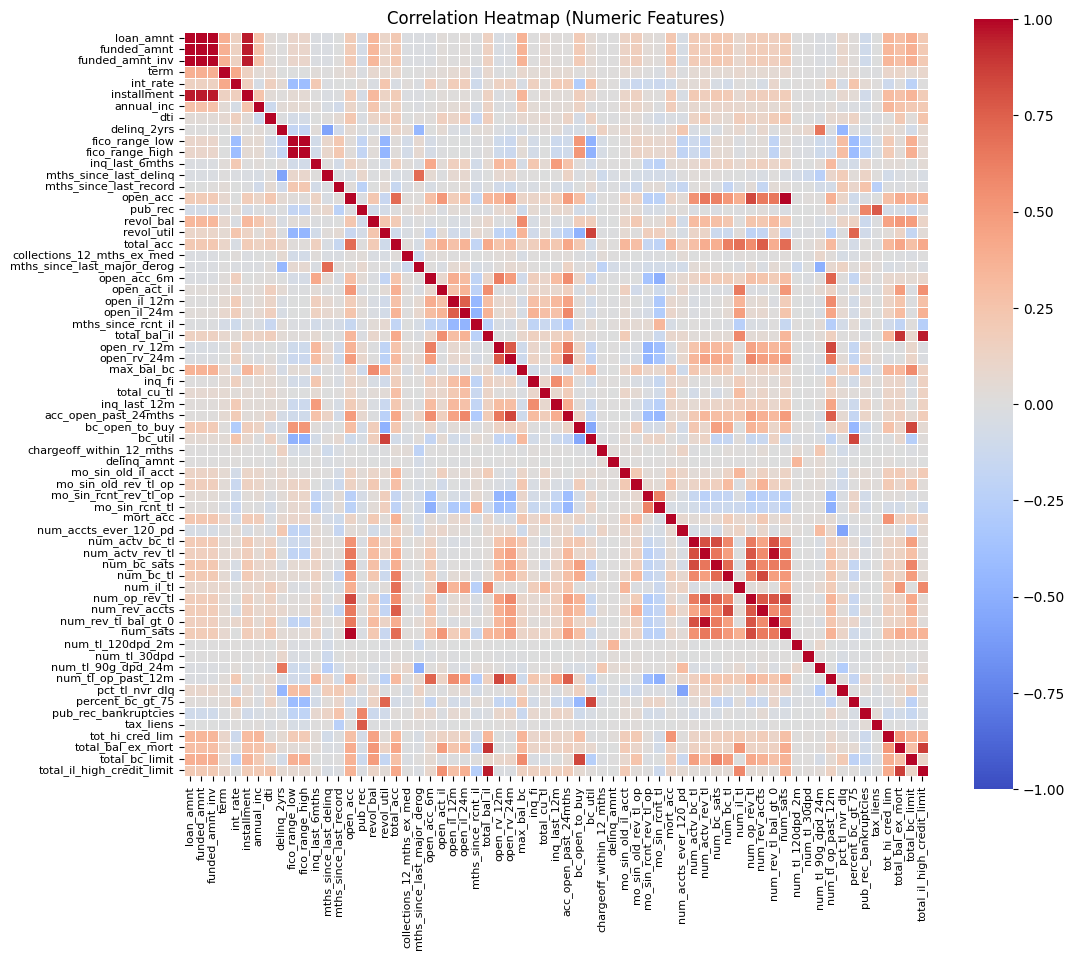

In [43]:
# correlation matrix
num_cols = data.select_dtypes(include=[np.number]).columns
corr = data[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.xticks(ticks=np.arange(len(corr.columns)) + 0.5, labels=corr.columns, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(len(corr.columns)) + 0.5, labels=corr.columns, rotation=0, fontsize=8)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [44]:
print(corr[corr>0.95])

                             loan_amnt  funded_amnt  funded_amnt_inv  term  \
loan_amnt                         1.00         1.00             1.00   NaN   
funded_amnt                       1.00         1.00             1.00   NaN   
funded_amnt_inv                   1.00         1.00             1.00   NaN   
term                               NaN          NaN              NaN  1.00   
int_rate                           NaN          NaN              NaN   NaN   
installment                       0.95         0.95             0.95   NaN   
annual_inc                         NaN          NaN              NaN   NaN   
dti                                NaN          NaN              NaN   NaN   
delinq_2yrs                        NaN          NaN              NaN   NaN   
fico_range_low                     NaN          NaN              NaN   NaN   
fico_range_high                    NaN          NaN              NaN   NaN   
inq_last_6mths                     NaN          NaN             

In [45]:
# remove columns with highly correlated variables for logistic regression
data_lr = data.drop(columns=['funded_amnt', 'funded_amnt_inv', 'installment', 'fico_range_low', 
                             'num_sats', 'num_rev_tl_bal_gt_0', 'total_il_high_credit_limit'])

In [47]:
data['title'].unique()

KeyError: 'title'